In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import soundfile as sf
import librosa
import numpy as np
import IPython.display as ipd
import tqdm
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
# Define the device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS device")
else:
    device = torch.device("cpu")
    print("MPS not available, using CPU")

Using MPS device


In [2]:
class AudioResidualLSTM(nn.Module):
    def __init__(self, input_channels=1, hidden_dim=64, num_layers=2, kernel_size=3):
        """
        Args:
            input_channels: 1 for mono, 2 for stereo.
            hidden_dim: The 'memory' size of the LSTM.
            num_layers: How many LSTM layers to stack.
            kernel_size: Used for a pre-processing convolution to help the LSTM.
        """
        super(AudioResidualLSTM, self).__init__()

        self.input_channels = input_channels
        self.hidden_dim = hidden_dim

        # 1. Pre-processing Layer: A small 1D Convolution.
        # This helps the model look at a tiny window of samples
        # rather than just a single isolated point.
        self.pre_conv = nn.Conv1d(
            in_channels=input_channels,
            out_channels=hidden_dim,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # 2. The Temporal Engine: LSTM
        # batch_first=True means input shape is (Batch, Sequence, Features)
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # 3. The Projection Head: The FC/Linear Layer
        # This maps the high-dimensional LSTM state back to audio amplitude.
        self.fc = nn.Linear(hidden_dim, input_channels)

    def forward(self, x, hidden=None):
        """
        x: Input tensor of shape (Batch, Sequence, Channels)
           Example: (32, 1024, 1) -> 32 chunks of 1024 samples each.
        """
        # Store the original input for the residual connection
        identity = x

        # --- Step 1: Pre-processing ---
        # Conv1d expects (Batch, Channels, Sequence), so we permute
        x_conv = x.permute(0, 2, 1)
        x_conv = self.pre_conv(x_conv)

        # Bring it back to (Batch, Sequence, Hidden_Dim) for the LSTM
        x_features = x_conv.permute(0, 2, 1)

        # --- Step 2: Temporal Modeling ---
        # lstm_out shape: (Batch, Sequence, Hidden_Dim)
        lstm_out, new_hidden = self.lstm(x_features, hidden)

        # --- Step 3: Projection ---
        # Map hidden features back to audio channels
        # residual shape: (Batch, Sequence, Channels)
        residual = self.fc(lstm_out)

        # --- Step 4: The Residual Connection (CRITICAL) ---
        # We add the learned distortion back to the original clean signal.
        # Output = Clean_Signal + Learned_Distortion
        output = identity + residual

        return output, new_hidden

In [3]:
class AudioAmpDataset(Dataset):
    def __init__(self, clean_path, target_path ,seq_len=512, calculate_norm=True, sample_rate=44100):
        """
        Args:
            clean_path: Path to the input (DI) audio file.
            target_path: Path to the target (Distorted) audio file.
            seq_len: The number of samples per chunk.
        """

        self.clean_path = clean_path
        self.target_path = target_path
        self.seq_len = seq_len
        self.sample_rate = sample_rate

        clean_info = sf.info(clean_path)
        target_info = sf.info(target_path)


        assert clean_info.frames == target_info.frames, "Clean and Target files must be the same length."

        self.total_frames = clean_info.frames

        self.clean_max = 1.0
        self.target_max = 1.0
        if calculate_norm:
            print("Calculating global maximums for normalization (this might take a few seconds)...")
            self._compute_global_max()

        # Calculate how many valid chunks
        self.num_chunks = self.total_frames // self.seq_len

    def __len__(self):
        return self.num_chunks

    def _compute_global_max(self, block_size=5):
        block_size = block_size * self.sample_rate  # Convert seconds to samples
        current_Train_max = 0.0
        current_Valid_max = 0.0
        total_block = self.total_frames // block_size + 1

        for block_i in range(total_block):
            start_frame = block_i * block_size
            frames_to_read = min(block_size, self.total_frames - start_frame)
            if frames_to_read <= 0:
                break
            Train_block, _ = sf.read(self.clean_path, frames=frames_to_read, start=start_frame, dtype='float32')
            Valid_block, _ = sf.read(self.target_path, frames=frames_to_read, start=start_frame, dtype='float32')
            Block_Train_max =  np.max(np.abs(Train_block))
            Block_Valid_max =  np.max(np.abs(Valid_block))

            if Block_Train_max > current_Train_max:
                current_Train_max = Block_Train_max
            if Block_Valid_max > current_Valid_max:
                current_Valid_max = Block_Valid_max

        self.clean_max = max(current_Train_max, 1e-8)
        self.target_max = max(current_Valid_max, 1e-8)
        print(f"Global Clean Max: {self.clean_max:.4f} | Global Target Max: {self.target_max:.4f}")
        return 1.0


    def __getitem__(self, idx):
        """
        This is where 'lazy loading' happens.
        It is only called when the DataLoader requests batch 'idx'.
        """

        start_frame = idx * self.seq_len

        # Read exactly 'seq_len' frames from disk
        clean_chunk, _ = sf.read(self.clean_path, frames=self.seq_len, start=start_frame, dtype='float32')
        target_chunk, _ = sf.read(self.target_path, frames=self.seq_len, start=start_frame, dtype='float32')

        # If stereo, convert to mono. soundfile returns shape (frames, channels)
        if clean_chunk.ndim > 1:
            clean_chunk = clean_chunk.mean(axis=1)
        if target_chunk.ndim > 1:
            target_chunk = target_chunk.mean(axis=1)


        clean_chunk = clean_chunk / self.clean_max
        target_chunk = target_chunk / self.target_max
        # Reshape to expected (Sequence, Features) which is (512, 1)
        clean_tensor = torch.tensor(clean_chunk, dtype=torch.float32).unsqueeze(-1)
        target_tensor = torch.tensor(target_chunk, dtype=torch.float32).unsqueeze(-1)

        return clean_tensor, target_tensor


In [4]:
dataset = AudioAmpDataset(
    clean_path="Data/ML Guitar_ Initial_Data.wav",
    target_path="Data/ML Guitar Target Data.wav",
    seq_len=512
)

train_loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=False,       # Shuffle the chunks for better training
    num_workers=0,      # Uses 2 background processes to read from disk concurrently
    pin_memory=True    # Speeds up transferring data to MPS/GPU
)

Calculating global maximums for normalization (this might take a few seconds)...
Global Clean Max: 0.9990 | Global Target Max: 0.5515


In [5]:
def ErrorToSignalLoss(predictions, targets):
    """
    A custom loss function that penalizes the model more when it produces
    large errors on high-amplitude sections of the audio.
    """

    # Calculate the absolute error
    error_esr = torch.sum(torch.abs(predictions - targets)**2)/torch.sum(torch.abs(targets)**2)
    error_dc = torch.sum(torch.abs(predictions - targets))**2/(torch.sum(torch.abs(targets)**2))

    # Return the mean of the weighted error as the loss
    return error_esr + error_dc


In [6]:

def train_model_with_loader(model, dataloader, epochs=5, device="mps"):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    model.to(device)
    model.train()

    for epoch in tqdm.tqdm(range(epochs), desc="Training Epochs"):
        epoch_loss = 0.0

        for batch_idx, (clean_batch, target_batch) in enumerate(dataloader):
            clean_batch = clean_batch.to(device)
            target_batch = target_batch.to(device)

            optimizer.zero_grad()

            predictions, _ = model(clean_batch)

            loss = criterion(predictions, target_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")
# Run it
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# device = torch.device("cpu")
model = AudioResidualLSTM(input_channels=1, hidden_dim=128)
train_model_with_loader(model, train_loader, epochs=5, device=device)

Training Epochs:  20%|██        | 1/5 [00:15<01:01, 15.47s/it]

Epoch [1/5], Loss: 0.006132


Training Epochs:  40%|████      | 2/5 [00:28<00:42, 14.30s/it]

Epoch [2/5], Loss: 0.005443


Training Epochs:  60%|██████    | 3/5 [00:42<00:27, 13.94s/it]

Epoch [3/5], Loss: 0.005121


Training Epochs:  80%|████████  | 4/5 [00:56<00:13, 13.80s/it]

Epoch [4/5], Loss: 0.004998


Training Epochs: 100%|██████████| 5/5 [01:09<00:00, 13.92s/it]

Epoch [5/5], Loss: 0.002859


In [7]:
def process_new_audio(model, input_file, output_file, device, clean_max, target_max, seq_len=48000):
    """
    Passes a raw audio file through the trained LSTM and saves the result.
    Updated to fix normalization mismatches and limit boundary artifacts.
    """
    model.eval() # Set model to inference mode

    # ==========================================
    # STEP 1: LOAD THE AUDIO
    # ==========================================
    print(f"Loading {input_file}...")
    audio, sr = librosa.load(input_file, sr=None, mono=True)

    # --- FIX 3: Training-Matched Normalization ---
    # Downscale the input using the exact maximum found during training
    # instead of librosa.util.normalize which changes the relative scale.
    audio = audio / clean_max

    # ==========================================
    # STEP 2: CHUNK THE AUDIO
    # ==========================================
    # Calculate padding so the last chunk is exactly seq_len
    # --- FIX 2: We use a massive block (default 48000) so boundaries are rare ---
    remainder = len(audio) % seq_len
    padding = 0
    if remainder != 0:
        padding = seq_len - remainder
        audio = np.pad(audio, (0, padding), mode='constant')

    # Reshape the 1D array into shape (Total_Chunks, Sequence_Length, 1)
    num_chunks = len(audio) // seq_len
    chunks = audio.reshape(num_chunks, seq_len, 1)

    # Convert to PyTorch Tensor
    tensor_chunks = torch.tensor(chunks, dtype=torch.float32)

    # ==========================================
    # STEP 3: PREDICT IN BATCHES
    # ==========================================
    hidden_state = None
    processed_chunks = []

    with torch.no_grad():
        for i in tqdm.tqdm(range(num_chunks), desc="Processing audio chunks"):
            # Shape: (1, seq_len, 1)
            batch = tensor_chunks[i : i + 1].to(device)

            # Model returns prediction and the new state
            pred, hidden_state = model(batch, hidden=hidden_state)

            processed_chunks.append(pred.cpu().numpy())

    # ==========================================
    # STEP 4: STITCH, DENORMALIZE, AND SAVE
    # ==========================================
    # Concatenate all batches back into a single array
    output_audio = np.concatenate(processed_chunks, axis=0)

    # Flatten back to a continuous 1D array
    output_audio = output_audio.flatten()

    # If we padded earlier, remove the padding at the very end
    if padding != 0:
        output_audio = output_audio[:-padding]

    # --- FIX 3 (Part 2): Training-Matched Denormalization ---
    # Upscale the output back to the target's original amplitude space
    output_audio = output_audio * target_max

    # Save the result
    print(f"Saving resulting audio to {output_file}...")
    sf.write(output_file, output_audio, sr)
    print("Done!")

    return output_audio

In [8]:
# Setup device (MPS for your Mac)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Move your trained model to the device
my_trained_model = model.to(device)

# Process a new riff
# Process a new riff
result = process_new_audio(
    model=my_trained_model,
    input_file="Data/ML Guitar_ Initial_Data_Cut.wav",
    output_file="Data/My_Distorted_Riff_Cut.wav",
    device=device,
    clean_max=dataset.clean_max,    # <--- Added
    target_max=dataset.target_max,  # <--- Added
    seq_len=48000                   # <--- Process in 1-second blocks (assuming 48kHz audio)
)

Loading Data/ML Guitar_ Initial_Data_Cut.wav...


Processing audio chunks: 100%|██████████| 10/10 [00:06<00:00,  1.47it/s]

Saving resulting audio to Data/My_Distorted_Riff_Cut.wav...
Done!


In [9]:
ipd.Audio(result, rate=44100)

In [10]:
targetAudio,_ = sf.read("Data/ML Guitar_ Target Data_Cut.wav", dtype='float32')
ipd.Audio(targetAudio, rate=44100)

In [11]:
ipd.Audio(result, rate=44100)

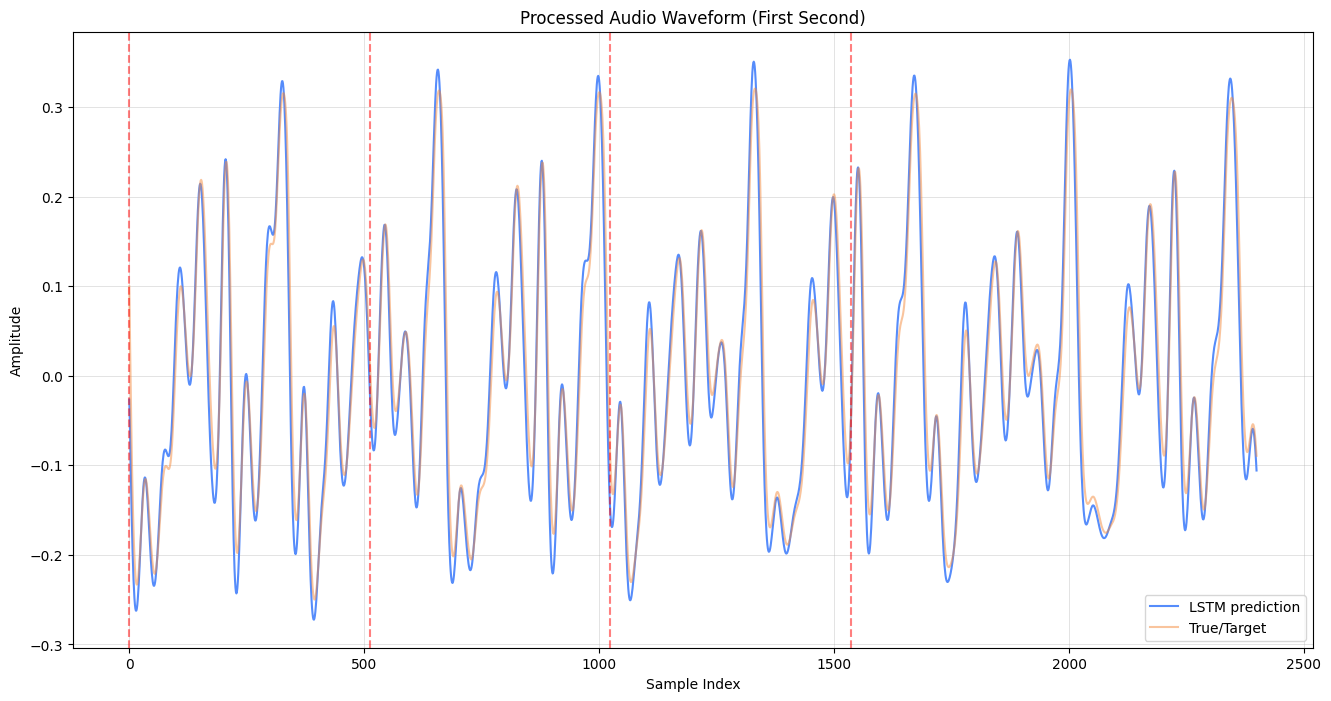

In [12]:
# plot waveform to check for zero crossings
sr = 48000

start = int(sr*8)
end = int(sr * 8.05)  # Plot the first 0.1 seconds (4410 samples)
plt.figure(figsize=(16, 8))
plt.plot(result[start:end], label = 'LSTM prediction')  # Plot the first second of audio
plt.plot(targetAudio[start:end], alpha=0.5, label = 'True/Target')  # Overlay the target audio for comparison
#make vertical lines at 512 sample intervals to show the chunk boundaries
for i in range(len(result[start:end]) // 512):
    plt.axvline(x=i*512, color='r', linestyle='--', alpha=0.5)
plt.title("Processed Audio Waveform (First Second)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()